In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [6]:
file_path = "mnist_train.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "oddrationale/mnist-in-csv",
    file_path
)

df.head()

/tmp/ipykernel_2919/1982738516.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'mnist-in-csv' dataset.


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df.head()
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (60000, 785)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


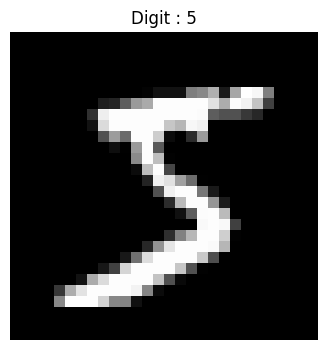

In [8]:
plt.figure(figsize=(4,4))

image = df.iloc[0,1:].values.reshape(28,28)

plt.imshow(image,cmap="gray")

plt.title(f"Digit : {df.iloc[0,0]}")

plt.axis("off")

plt.show()

In [9]:
# Check missing values
print(df.isnull().sum())

# Features
X = df.iloc[:,1:].values

# Target
y = df.iloc[:,0].values

# Normalize pixels
X = X / 255.0

# Train-Test Split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# One-Hot Encoding
y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

print("Training Shape :",X_train.shape)
print("Testing Shape :",X_test.shape)

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64
Training Shape : (48000, 784)
Testing Shape : (12000, 784)


In [10]:
model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(
    128,
    activation="relu",
    input_shape=(784,)
))

# Hidden Layer 2
model.add(Dense(
    64,
    activation="relu"
))

# Output Layer
model.add(Dense(
    10,
    activation="softmax"
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(

    X_train,

    y_train,

    epochs=10,

    validation_split=0.2,

    verbose=1

)

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9143 - loss: 0.2950 - val_accuracy: 0.9479 - val_loss: 0.1738
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9632 - loss: 0.1263 - val_accuracy: 0.9555 - val_loss: 0.1439
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9743 - loss: 0.0857 - val_accuracy: 0.9490 - val_loss: 0.1633
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9796 - loss: 0.0635 - val_accuracy: 0.9690 - val_loss: 0.1043
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9836 - loss: 0.0505 - val_accuracy: 0.9640 - val_loss: 0.1284
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9878 - loss: 0.0399 - val_accuracy: 0.9690 - val_loss: 0.1177
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9897 - loss: 0.0309 - val_accuracy: 0.9712 - val_loss: 0.0980
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9912 - loss: 0.0265 - 

In [15]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions,axis=1)

y_true = np.argmax(y_test,axis=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [16]:
loss,accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy :",accuracy)

Test Accuracy : 0.9726666808128357


In [17]:
print(classification_report(
    y_true,
    y_pred
))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1175
           1       0.99      0.98      0.99      1322
           2       0.97      0.97      0.97      1174
           3       0.99      0.92      0.95      1219
           4       0.98      0.98      0.98      1176
           5       0.92      0.99      0.96      1104
           6       0.98      0.98      0.98      1177
           7       0.98      0.98      0.98      1299
           8       0.95      0.97      0.96      1160
           9       0.97      0.97      0.97      1194

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



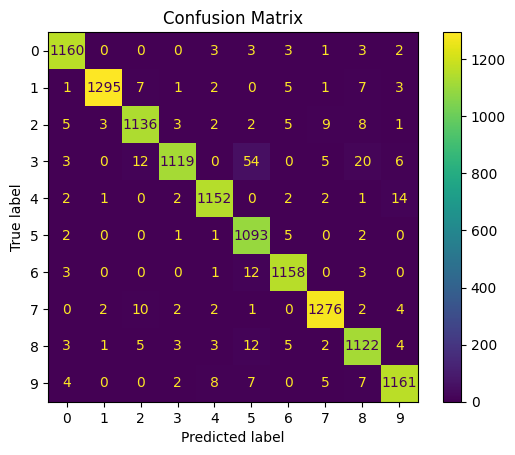

In [18]:
cm = confusion_matrix(
    y_true,
    y_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title("Confusion Matrix")

plt.show()

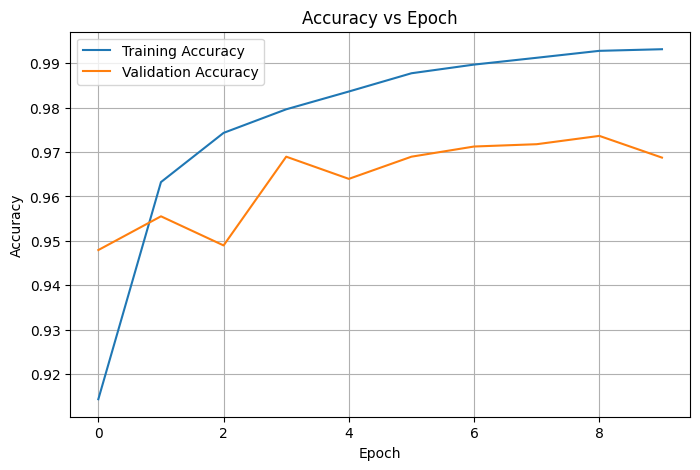

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Epoch")

plt.legend()

plt.grid(True)

plt.show()

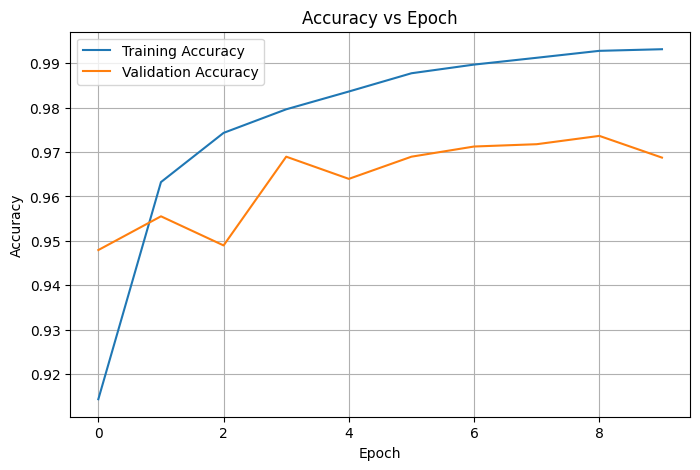

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Epoch")

plt.legend()

plt.grid(True)

plt.show()